# **1. 논리 회귀**

논리 회귀(Logistic Regression)는 주어진 입력 데이터를 기반으로 두 가지 이상의 범주로 분류하는 지도 학습 알고리즘이다. 주로 이진 분류 문제에 사용되며, **입력 변수의 선형 결합을 통해 특정 사건이 발생할 확률을 예측**한다. 이 알고리즘은 **시그모이드(Sigmoid) 함수 또는 로지스틱 함수라는 비선형 함수를 사용하여 예측값을 0과 1 사이의 확률로 변환한다. 모델의 결과는 일반적으로 특정 임계값(예: 0.5)을 기준으로 두 범주 중 하나로 분류된다.** 예를 들어, 이메일이 스팸인지 아닌지를 판별하거나 환자의 병 진단 여부를 예측하는 데 사용될 수 있다. 논리 회귀는 계산이 비교적 간단하고 해석이 용이하여 머신러닝에서 널리 사용되는 알고리즘이다.

### ※ 시그모이드 함수
시그모이드 함수(Sigmoid Function)는 입력 값을 받아서 이를 0과 1 사이의 값으로 변환하는 수학 함수이다. 주로 확률을 예측해야 하는 문제에서 사용된다. 논리 회귀(Logistic Regression)와 인공신경망(Artificial Neural Network)에서 매우 중요한 역할을 한다(e: 자연 상수로, 약 2.718).

![sigmoid](./images/sigmoid.png)

![시그모이드 예](./images/시그모이드%20예.png)

# **2. 단항 논리 회귀**

단항 논리 회귀(Univariate Logistic Regression)는 **하나의 독립 변수(입력 변수)를 사용하여 이진 분류 문제를 해결하는 논리 회귀(Logistic Regression)의 한 형태**이다. 예를 들어, 학생의 하루 공부 시간(독립 변수)에 따라 시험 합격 여부(종속 변수: 합격/불합격)를 예측하는 경우가 여기에 해당한다. 단항 논리 회귀는 입력 변수의 값을 시그모이드(Sigmoid) 함수에 전달하여 해당 사건(예: 합격)이 발생할 확률(0과 1 사이의 값)을 계산한다. 이후 이 **확률 값이 특정 임계값(일반적으로 0.5)을 초과하면 한 클래스로, 그렇지 않으면 다른 클래스로 분류**한다. 단항 논리 회귀는 간단하면서도 직관적이어서 이진 분류 문제를 설명하고 해석하는 데 자주 사용된다.

In [45]:
import torch
import torch.nn as nn

In [46]:
x = torch.tensor([1.0, 2.0, 3.0])
w = torch.tensor([0.1, 0.2, 0.3])
b = torch.tensor(0.5)

# z = W1*x1 + W2*x2 + W3*x3 +b
# z = 0.1*1.0 + 0.2*2.0 + 0.3*3.0 + 0.5
# z: 로짓(Logit);로그 오즈(Log-Odds)
# 로짓 -> 확률
z = torch.dot(w, x) + b
ouput = nn.Sigmoid()(z)
print(ouput)

tensor(0.8699)


In [47]:
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(2026)

torch.Size([8, 1])
torch.Size([8, 1])


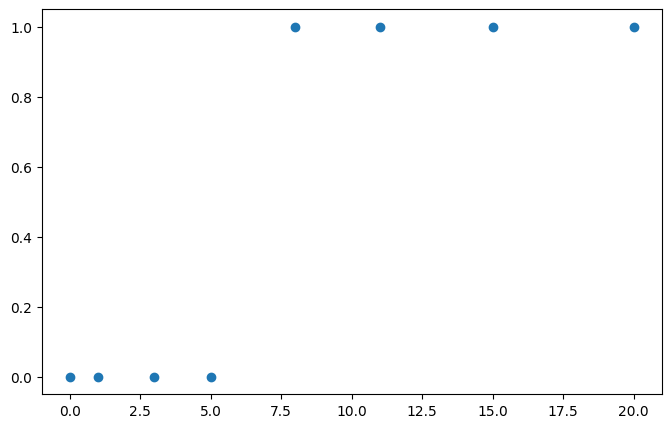

In [48]:
x_train = torch.FloatTensor([[0], [1], [3], [5], [8], [11], [15], [20]])
y_train = torch.FloatTensor([[0], [0], [0], [0], [1], [1], [1], [1]])
print(x_train.shape)
print(y_train.shape)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train)

In [49]:
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)
print(list(model.parameters()))

y_pred = model(x_train)
y_pred

[Parameter containing:
tensor([[-0.6950]], requires_grad=True), Parameter containing:
tensor([-0.4962], requires_grad=True)]


tensor([[3.7844e-01],
        [2.3304e-01],
        [7.0353e-02],
        [1.8499e-02],
        [2.3372e-03],
        [2.9109e-04],
        [1.8061e-05],
        [5.5911e-07]], grad_fn=<SigmoidBackward0>)

### BCE 손실 함수
Binary Cross Entropy (BCE)는 이진 분류 문제에서 모델이 예측한 확률 분포와 실제 정답 레이블 사이의 차이를 측정하는 손실 함수(Loss Function)이다. BCE는 예측된 확률 값과 실제 값(0 또는 1) 사이의 차이를 로그 확률로 변환하여 손실을 계산한다.

![BCE Loss](./images/BCE%20Loss.png)

![BCE Loss 예](./images/BCE%20Loss%20예.png)

In [50]:
loss = nn.BCELoss()(y_pred, y_train)
loss

tensor(5.0440, grad_fn=<BinaryCrossEntropyBackward0>)

In [51]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [52]:
epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.BCELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

Epoch: 0/1000 Loss: 5.043980
Epoch: 100/1000 Loss: 0.395748
Epoch: 200/1000 Loss: 0.367399
Epoch: 300/1000 Loss: 0.343098
Epoch: 400/1000 Loss: 0.322116
Epoch: 500/1000 Loss: 0.303868
Epoch: 600/1000 Loss: 0.287886
Epoch: 700/1000 Loss: 0.273790
Epoch: 800/1000 Loss: 0.261278
Epoch: 900/1000 Loss: 0.250103
Epoch: 1000/1000 Loss: 0.240065


In [53]:
list(model.parameters())

[Parameter containing:
 tensor([[0.3519]], requires_grad=True),
 Parameter containing:
 tensor([-1.7598], requires_grad=True)]

In [54]:
x_test = torch.FloatTensor([[10]])
y_pred = model(x_test)
y_pred

tensor([[0.8531]], grad_fn=<SigmoidBackward0>)

In [55]:
# 임계치 설정하기
# 0.5보다 크거나 같으면 1
# 0.5보다 작으면 0
y_bool = (y_pred >= 0.5).float()
y_bool

tensor([[1.]])

# **3. 다항 논리 회귀**

다항 논리 회귀(Multinomial Logistic Regression)는 **종속 변수가 세 개 이상의 범주로 나뉘는 다중 클래스 분류 문제를 해결하는 알고리즘**이다. 예를 들어, 과일의 색깔이 빨강, 노랑, 초록 중 하나로 분류되는 문제에서 사용할 수 있다. 이 알고리즘은 각 클래스에 대한 확률을 예측하기 위해 **소프트맥스(Softmax) 함수**를 사용한다. 소프트맥스 함수는 각 클래스에 속할 확률을 0과 1 사이의 값으로 변환하며, 모든 클래스의 확률 합이 1이 되도록 정규화한다. 모델은 입력 데이터가 특정 클래스에 속할 가능성을 계산한 뒤, 가장 높은 확률을 가진 클래스를 최종 예측 값으로 선택한다. 다항 논리 회귀는 자연어 처리, 이미지 분류, 그리고 다양한 다중 클래스 분류 문제에서 널리 사용된다.

In [56]:
x_train = [
    # 국어, 영어, 수학, 출석
    [55, 58, 60, 70],   # C
    [60, 62, 65, 75],   # C
    [63, 65, 67, 78],   # C

    [72, 74, 75, 85],   # B
    [75, 78, 80, 88],   # B
    [80, 82, 81, 90],   # B

    [88, 90, 91, 95],   # A
    [92, 94, 93, 97],   # A
    [95, 96, 98, 98],   # A
    [98, 99, 100, 100]  # A
]

y_train = [
    0, 0, 0,   # C등급
    1, 1, 1,   # B등급
    2, 2, 2, 2 # A등급
]

x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)
print(x_train.shape)
print(y_train.shape)

torch.Size([10, 4])
torch.Size([10])


In [57]:
model = nn.Sequential(
    nn.Linear(4, 3)
)
model

Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
)

![행렬계산](./images/행렬계산.png)

In [58]:
y_pred = model(x_train)
y_pred

tensor([[-41.9305, -34.7673,  23.2490],
        [-44.9524, -36.7496,  25.4191],
        [-46.5456, -38.4367,  26.3142],
        [-52.2771, -42.1943,  29.1668],
        [-55.7500, -43.7859,  30.4298],
        [-56.8302, -45.2004,  31.2815],
        [-63.3086, -47.4136,  34.2927],
        [-65.1011, -48.8881,  35.0556],
        [-67.6916, -48.5744,  36.6465],
        [-69.2794, -49.8079,  37.4010]], grad_fn=<AddmmBackward0>)

### CrossEntropyLoss
CrossEntropyLoss는 **다중 클래스 분류(Multiclass Classification) 문제에서 모델의 예측과 실제 정답 레이블 간의 차이를 측정하는 손실 함수**(Loss Function)이다. 이 함수는 **모델이 예측한 확률 분포와 실제 레이블(정답) 간의 불확실성을 수치화**한다. CrossEntropyLoss는 주로 Softmax 함수와 함께 사용된다. Softmax는 각 클래스에 대한 확률 분포를 제공하며, CrossEntropyLoss는 이 확률 분포와 실제 레이블 간의 차이를 계산한다. 예측이 실제 레이블과 가까울수록 손실 값이 작아지며, 예측이 틀릴수록 손실 값은 커진다.

![CrossEntropyLoss](./images/CrossEntropyLoss.png)

![CrossEntropyLoss 예시](./images/CrossEntropyLoss%20예시.png)

### Softmax
Softmax 함수는 다중 클래스 분류(Multiclass Classification) 문제에서 사용되는 **활성화 함수**(Activation Function)입니다. 이 함수는 주어진 입력 벡터의 각 요소를 확률 분포(probability distribution)로 변환합니다. 즉, 각 클래스에 대한 **예측값을 0과 1 사이의 값으로 변환**하며, 모든 클래스의 확률 합이 항상 1이 되도록 정규화합니다.

![Softmax](./images/Softmax.png)

![Softmax 예시](./images/Softmax%20예시.png)

In [59]:
loss = nn.CrossEntropyLoss()(y_pred, y_train)
loss

tensor(43.0469, grad_fn=<NllLossBackward0>)

In [60]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [61]:
epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.CrossEntropyLoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

Epoch: 0/1000 Loss: 43.046947
Epoch: 100/1000 Loss: 90.428192
Epoch: 200/1000 Loss: 61.534607
Epoch: 300/1000 Loss: 55.375122
Epoch: 400/1000 Loss: 79.485916
Epoch: 500/1000 Loss: 22.985962
Epoch: 600/1000 Loss: 5.468316
Epoch: 700/1000 Loss: 20.016703
Epoch: 800/1000 Loss: 23.576168
Epoch: 900/1000 Loss: 25.971176
Epoch: 1000/1000 Loss: 0.000149


In [66]:
x_test = torch.FloatTensor([[90, 91, 92, 93]])
y_pred = model(x_test)
y_pred

tensor([[-101.8973,  -15.1790,   41.5880]], grad_fn=<AddmmBackward0>)

In [67]:
y_prob = nn.Softmax(dim=1)(y_pred) # x_test 값이 열로 되어 있음
y_prob

tensor([[0.0000e+00, 2.2202e-25, 1.0000e+00]], grad_fn=<SoftmaxBackward0>)

In [69]:
print(f'0일 확률: {y_prob[0][0]:.2f}')
print(f'1일 확률: {y_prob[0][1]:.2f}')
print(f'2일 확률: {y_prob[0][2]:.2f}')

0일 확률: 0.00
1일 확률: 0.00
2일 확률: 1.00


In [70]:
torch.argmax(y_prob, axis=1)

tensor([2])